In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
funnel = pd.read_csv(r"C:\Users\kuldiep\Downloads\Data\funnel_user_summary.csv")
orders = pd.read_csv(r"C:\Users\kuldiep\Downloads\Data\orders_clean.csv")

In [5]:
funnel_counts = pd.DataFrame({
    "Stage": ["Visit", "Signup", "Activate", "Add to Cart", "Purchase"],
    "Users": [
        funnel["visit_flag"].sum(),
        funnel["signup_flag"].sum(),
        funnel["activate_flag"].sum(),
        funnel["add_to_cart_flag"].sum(),
        funnel["purchase_flag"].sum()
    ]
})

print(funnel_counts)

         Stage   Users
0        Visit  150000
1       Signup  112650
2     Activate   73225
3  Add to Cart   40147
4     Purchase   28909


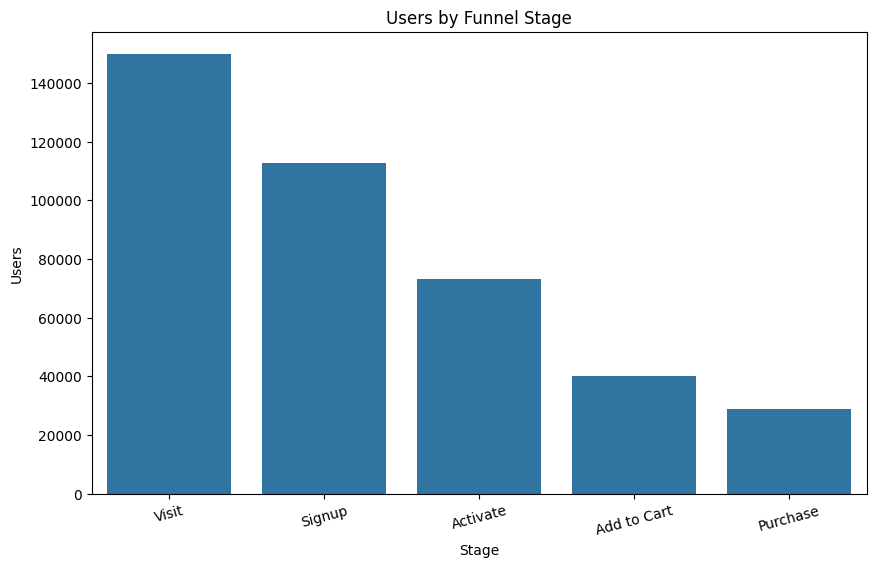

In [6]:
plt.figure(figsize=(10, 6))
sns.barplot(data=funnel_counts, x="Stage", y="Users")
plt.title("Users by Funnel Stage")
plt.xticks(rotation=15)
plt.show()

In [7]:
device_perf = funnel.groupby("device").agg(
    users=("user_id", "count"),
    purchasers=("purchase_flag", "sum"),
    revenue=("total_revenue", "sum")
).reset_index()

device_perf["conversion_pct"] = round(device_perf["purchasers"] / device_perf["users"] * 100, 2)
print(device_perf)

    device   users  purchasers      revenue  conversion_pct
0  Desktop   37538        7294  18879609.47           19.43
1   Mobile  104935       20168  51983459.94           19.22
2   Tablet    7527        1447   3647422.37           19.22


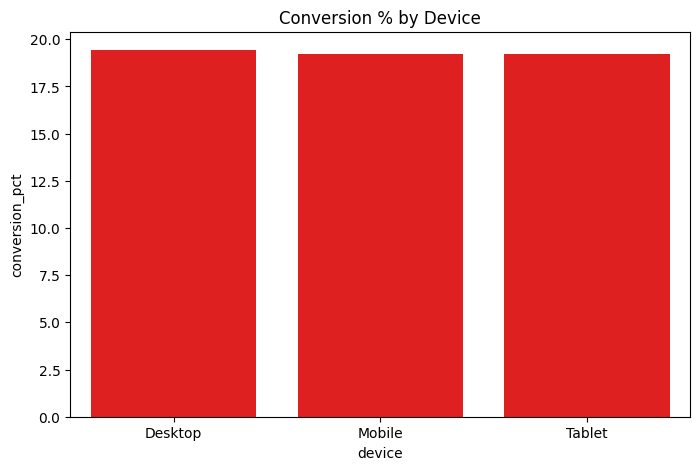

In [11]:
plt.figure(figsize=(8, 5))
sns.barplot(data=device_perf, x="device", y="conversion_pct", color = "red")
plt.title("Conversion % by Device")
plt.show()

In [9]:
channel_perf = funnel.groupby("channel").agg(
    users=("user_id", "count"),
    purchasers=("purchase_flag", "sum"),
    revenue=("total_revenue", "sum")
).reset_index()

channel_perf["conversion_pct"] = round(channel_perf["purchasers"] / channel_perf["users"] * 100, 2)
print(channel_perf)

        channel  users  purchasers      revenue  conversion_pct
0     Affiliate  24925        4891  12602362.91           19.62
1         Email  25172        4845  12554459.34           19.25
2  Facebook Ads  24959        4807  12306051.17           19.26
3    Google Ads  25150        4799  12360126.01           19.08
4       Organic  24898        4810  12396348.24           19.32
5      Referral  24896        4757  12291144.11           19.11


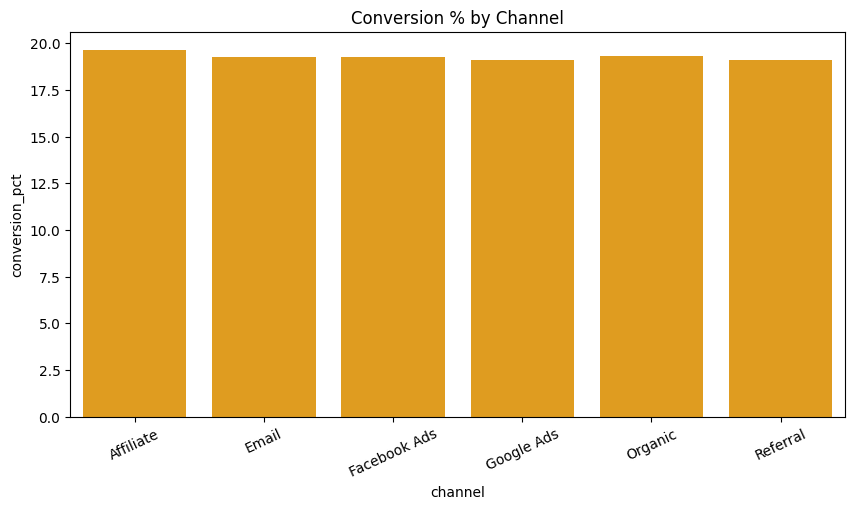

In [12]:
plt.figure(figsize=(10, 5))
sns.barplot(data=channel_perf, x="channel", y="conversion_pct", color = "orange")
plt.title("Conversion % by Channel")
plt.xticks(rotation=25)
plt.show()

In [13]:
country_perf = funnel.groupby("country").agg(
    users=("user_id", "count"),
    purchasers=("purchase_flag", "sum"),
    revenue=("total_revenue", "sum")
).reset_index()

country_perf["conversion_pct"] = round(country_perf["purchasers"] / country_perf["users"] * 100, 2)
print(country_perf)

     country  users  purchasers      revenue  conversion_pct
0  Australia  21506        4101  10516349.29           19.07
1     Canada  21622        4230  10828176.76           19.56
2    Germany  21570        4115  10610923.64           19.08
3      India  21127        4043  10475859.42           19.14
4        Uae  21470        4172  10811534.29           19.43
5         Uk  21338        4108  10585576.79           19.25
6        Usa  21367        4140  10682071.59           19.38


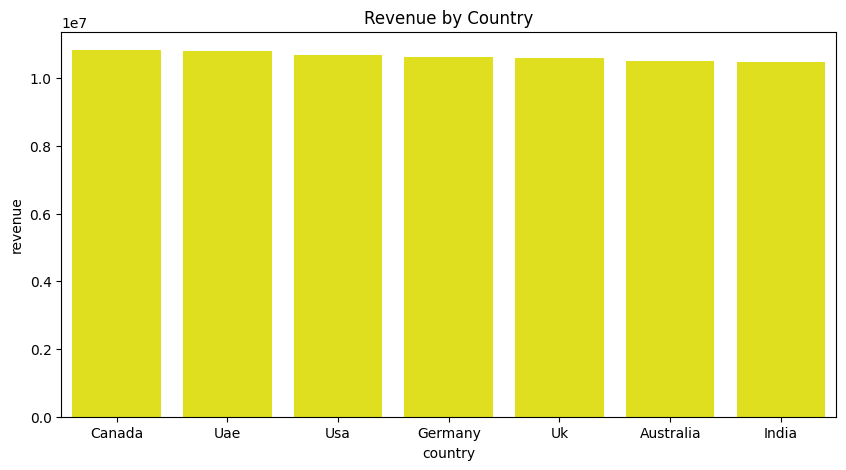

In [14]:
plt.figure(figsize=(10, 5))
sns.barplot(data=country_perf.sort_values("revenue", ascending=False), x="country", y="revenue", color = "yellow")
plt.title("Revenue by Country")
plt.show()

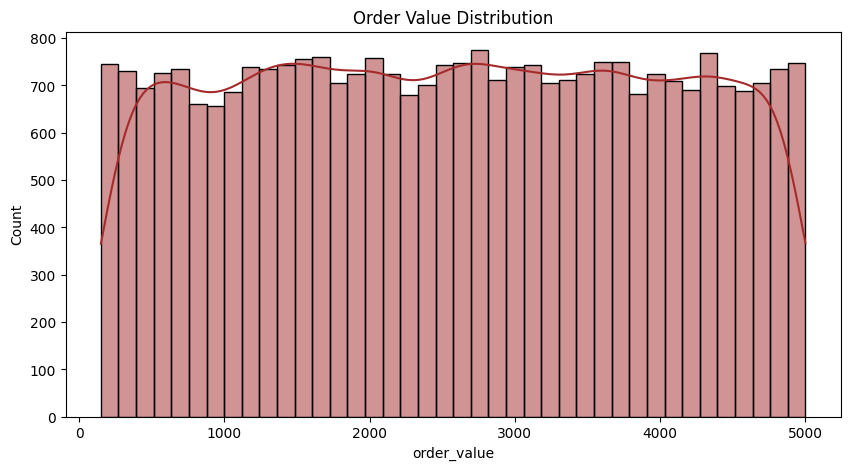

In [15]:
plt.figure(figsize=(10, 5))
sns.histplot(orders["order_value"], bins=40, kde=True, color = "brown")
plt.title("Order Value Distribution")
plt.show()

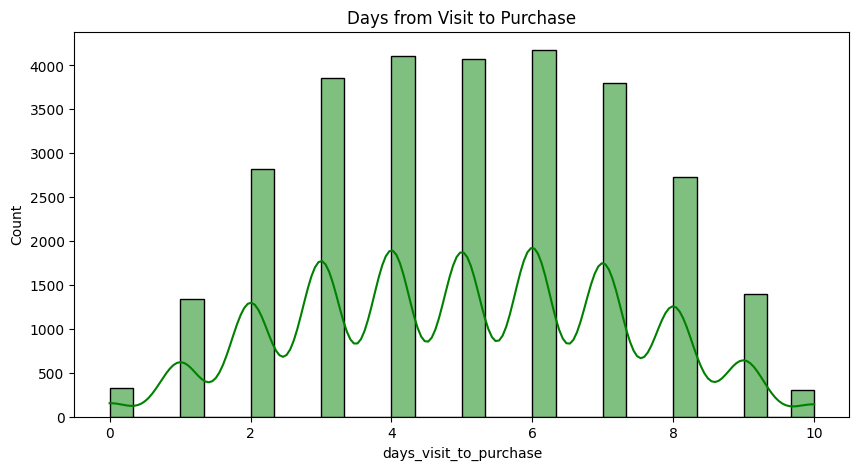

In [17]:
converted = funnel[funnel["purchase_flag"] == 1]

plt.figure(figsize=(10, 5))
sns.histplot(converted["days_visit_to_purchase"].dropna(), bins=30, kde=True, color = "green")
plt.title("Days from Visit to Purchase")
plt.show()

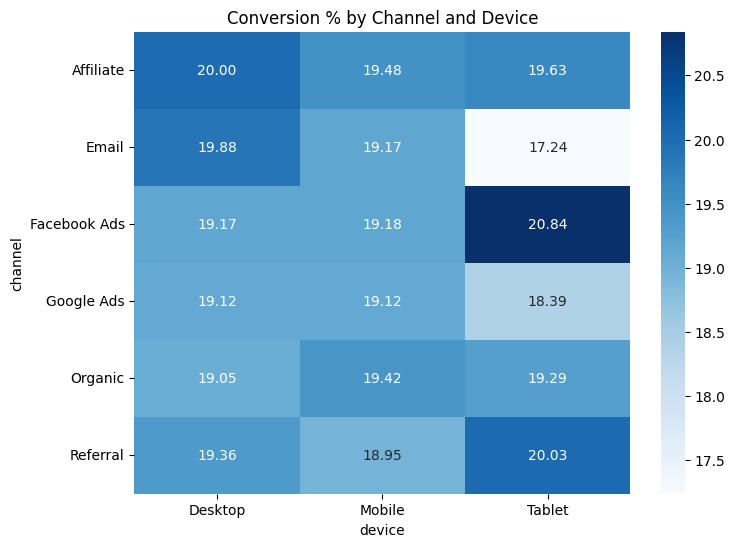

In [18]:
heatmap_df = funnel.groupby(["channel", "device"]).agg(
    users=("user_id", "count"),
    purchasers=("purchase_flag", "sum")
).reset_index()

heatmap_df["conversion_pct"] = round(heatmap_df["purchasers"] / heatmap_df["users"] * 100, 2)
heatmap_pivot = heatmap_df.pivot(index="channel", columns="device", values="conversion_pct")

plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_pivot, annot=True, cmap="Blues", fmt=".2f")
plt.title("Conversion % by Channel and Device")
plt.show()